In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

# Analysis of Parameters

We look at how differences in the reproduction number $R_0$ and mortality factor $m$ affect the expected present value.

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8 7.
 7.2 7.4 7.6 7.8 8.  8.2 8.4 8.6 8.8 9.  9.2 9.4 9.6 9.8]


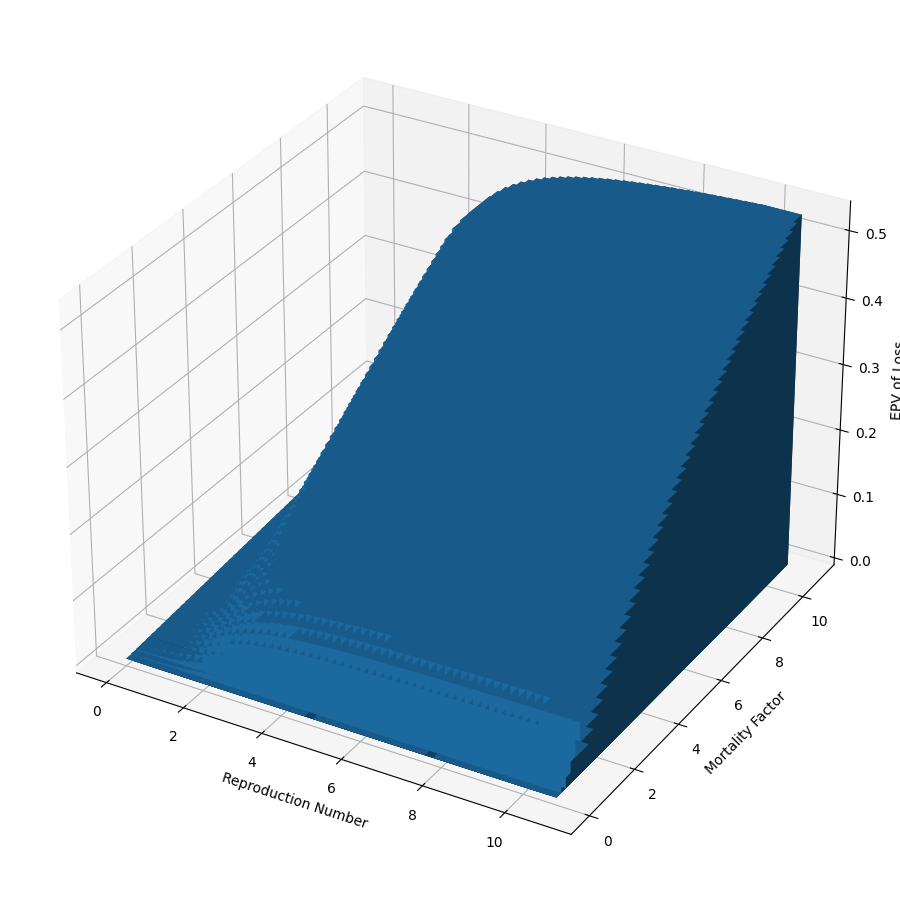

'print(y0[999,3])\ntpx = y0[:,3]\nmu_xt = mu*(1+mort_factor*y0[:,1])\ndiscount = np.exp(-delta *t)\nintegrand_ben = DB* tpx * mu_xt *discount\nintegrand_prem = P * tpx * discount\nEPV_ben = spi.trapezoid(integrand_ben,t)\nEPV_prem = spi.trapezoid(integrand_prem,t)\nprint(EPV_ben)\nprint(EPV_prem)\nprint("Loss of: ", EPV_ben + EPV_prem)'

In [10]:
mu = 0.1
mort_factor = 3
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
#ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 5
DB = 1 #death benefit
P = -mu*DB #premium calculated using equiv principle, assuming no pandemic

def ddt(u,t,params):
    (R0, mort_factor) = params
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt

def find_EPV(r,m,infected = 0.05): #finds the EPV of loss for a given mort factor, reproduction number, % of pop initially infected 
  t = np.linspace(0,5,1000)
  R0 = r
  mort_factor = m
  ic = np.array([1-infected,infected,0,1,0])
  y0 = spi.odeint(lambda u,t: ddt(u,t,(R0,mort_factor)), ic, t)
  tpx = y0[:,3]
  mu_xt = mu*(1+mort_factor*y0[:,1])
  discount = np.exp(-delta *t)
  integrand_ben = DB* tpx * mu_xt *discount
  integrand_prem = P * tpx * discount
  EPV_ben = spi.trapezoid(integrand_ben,t)
  EPV_prem = spi.trapezoid(integrand_prem,t)
  return EPV_ben + EPV_prem
#making 3d graph of EPV for different R0, mort factors
granularity = 0.2

_R0_vals = np.arange(0,10,granularity)
print(_R0_vals)
_mort_vals = np.arange(0,10,granularity)
_xx, _yy = np.meshgrid(_R0_vals, _mort_vals)

R0_vals, mort_vals = _xx.ravel(), _yy.ravel()

_top = np.zeros_like(_xx,dtype=float)

for i in range(len(_R0_vals)):
   for j in range(len(_mort_vals)):
      _top[j][i] = find_EPV(_R0_vals[i],_mort_vals[j])

top = _top.ravel()


bottom = np.zeros_like(top)
width = depth = 1
fig = plt.figure(figsize=(25, 30))
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(R0_vals, mort_vals, bottom, width, depth, top, shade=True)

ax1.set_xlabel("Reproduction Number")
ax1.set_ylabel("Mortality Factor")
ax1.set_zlabel("EPV of Loss")
plt.show()



'''print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
print(EPV_ben)
print(EPV_prem)
print("Loss of: ", EPV_ben + EPV_prem)'''



(50, 50)
10


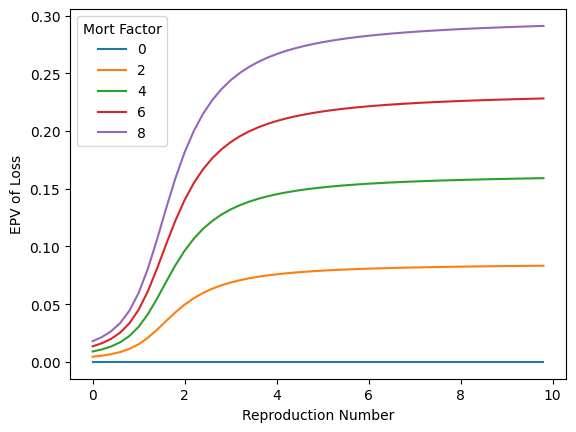

In [4]:
# Affect of R0 for fixed mortality factor

#TODO: add vertical marker for inflection point R0 * S = 1, do more analysis related to this inflection point
x = _R0_vals
print(_top.shape)
increment = _top.shape[0]//5
print(increment)
for i in range(5):

  y = _top[increment*i,:]
  l = str(i*2)
  plt.plot(x,y, label=l)


plt.legend(title="Mort Factor")
plt.xlabel("Reproduction Number")
plt.ylabel("EPV of Loss")
plt.show()



(50, 50)
10


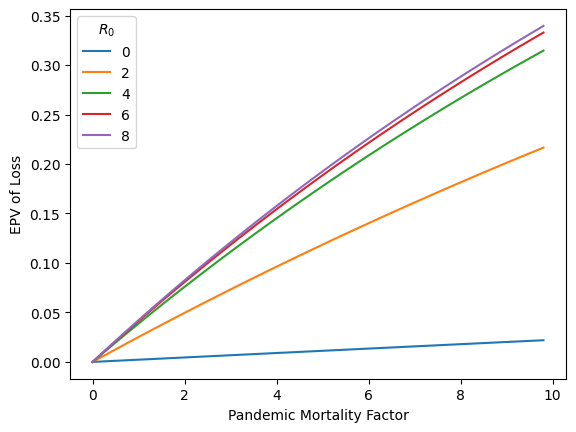

In [5]:
# Affect of Mortality factor for fixed R0

x = _mort_vals
print(_top.shape)
increment = _top.shape[0]//5
print(increment)
for i in range(5):

  y = _top[:,increment*i]
  l = str(i*2)
  plt.plot(x,y, label=l)

plt.legend(title="$R_0$")
plt.xlabel("Pandemic Mortality Factor")
plt.ylabel("EPV of Loss")

plt.show()
